In [4]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Réduit les logs verbeux
# Facultatif : désactiver cuDNN pour RNN
# os.environ['TF_USE_CUDNN_RNN'] = '0'

import tensorflow as tf

# Initialisation manuelle propre du GPU
physical_devices = tf.config.list_physical_devices('GPU')
if physical_devices:
    try:
        tf.config.experimental.set_memory_growth(physical_devices[0], True)
        print("GPU initialisé avec mémoire dynamique.")
    except Exception as e:
        print("Erreur d'initialisation GPU :", e)
else:
    print("Aucun GPU détecté.")



GPU initialisé avec mémoire dynamique.


In [5]:
from google.colab import files
uploaded = files.upload()  # Permet d’uploader un fichier CSV

import pandas as pd
df = pd.read_csv("collect_data.csv")
print(df.head())
print(f"Donnees chargees avec succes : {df.shape[0]} lignes, {df.shape[1]} colonnes.")
print("Classes disponibles:", df['label'].unique())
print("Distribution:")
print(df['label'].value_counts())

Saving collect_data.csv to collect_data.csv
        id_sensor                       state_topic  \
0  sensor_default  sensors/consommation/data_sensor   
1  sensor_default  sensors/consommation/data_sensor   
2  sensor_default  sensors/consommation/data_sensor   
3  sensor_default  sensors/consommation/data_sensor   
4  sensor_default  sensors/consommation/data_sensor   

                    timestamp  consommation unit_of_measurement  temperature  \
0  2025-07-29T17:17:26.058028          1.57                 kWh         -8.0   
1  2025-07-29T17:17:31.063457          1.48                 kWh        -13.0   
2  2025-07-29T17:17:36.068948          2.34                 kWh          6.0   
3  2025-07-29T17:17:41.074511          2.64                 kWh         13.0   
4  2025-07-29T17:17:46.080149          2.19                 kWh         17.0   

   light detecteur door connectivity    ip_source   label  
0   37.0        ON  OFF           ON  192.168.2.3  normal  
1   18.0       OFF   ON 

In [6]:
#Normalisation des donnees

from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split
import joblib
import numpy as np

# Conversion des colonnes 'detecteur', 'door' et 'connectivity' en valeurs binaires (1 pour ON, 0 pour OFF)
for column in ["detecteur", "door", "connectivity"]:
    df[column] = df[column].apply(lambda x: 1 if x == "ON" else 0)

# Encodage des IDs capteurs
#ID_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
#sensor_encoder = LabelEncoder()
#df[['id_sensor']] = ID_encoder.fit_transform(np.array(df["id_sensor"]).reshape(-1, 1))

# Gestion des IPs
#df['ip_source'] = df['ip_source'].apply(lambda x: 3 if x == "192.168.2.3" else 4)

# Vérification des valeurs manquantes
#missing_values = df.isnull().sum()
#if missing_values.sum() > 0:
#    print("Valeurs manquantes détectees :")
#    print(missing_values[missing_values > 0])

# Exclure les colonnes non numériques et separation des features/labels
X = df.drop(columns=["id_sensor", "timestamp", "unit_of_measurement", "state_topic", "ip_source", "label"]).values

# Encodage des labels
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['label'])

# Normalisation des features numériques
scaler = MinMaxScaler()
X_scaler = scaler.fit_transform(X)

# Création de séquences temporelles
n_steps = 200
X_sequences = []
y_sequences = []

for i in range(n_steps, len(X_scaler)):
    X_sequences.append(X_scaler[i-n_steps:i])
    y_sequences.append(y[i])

X_sequences = np.array(X_sequences)
y_sequences = np.array(y_sequences)

X_train, X_test, y_train, y_test = train_test_split(
    X_sequences, y_sequences, test_size=0.2, stratify=y_sequences, random_state=42
)

# Sauvegarde
joblib.dump(scaler, "scaler.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")
#joblib.dump(ID_encoder, "ID_encoder.pkl")

np.save("X_train.npy", X_train)
np.save("X_test.npy", X_test)
np.save("y_train.npy", y_train)
np.save("y_test.npy", y_test)

print("Pretraitement bien termine")

Pretraitement bien termine


In [7]:
!pip3 install torch torchaudio torchvision torchtext torchdata

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 45.3 MB/s eta 0:00:00


In [8]:
    import torch
    import torchvision
    import torchaudio
    import numpy
    import pandas
    import seaborn
    import tqdm
    import matplotlib

    print(f"Torch version: {torch.__version__}")
    print(f"Torchvision version: {torchvision.__version__}")
    print(f"Torchaudio version: {torchaudio.__version__}")
    print(f"Numpy version: {numpy.__version__}")
    print(f"Pandas version: {pandas.__version__}")
    print(f"Seaborn version: {seaborn.__version__}")
    print(f"Tqdm version: {tqdm.__version__}")
    print(f"Matplotlib version: {matplotlib.__version__}")

Torch version: 2.9.0+cu126
Torchvision version: 0.24.0+cu126
Torchaudio version: 2.9.0+cu126
Numpy version: 2.0.2
Pandas version: 2.2.2
Seaborn version: 0.13.2
Tqdm version: 4.67.1
Matplotlib version: 3.10.0


Train: (4992, 200, 6), (4992,)
Val: (1248, 200, 6), (1248,)
Test: (1560, 200, 6), (1560,)
Mémoire GPU nettoyee
Device utilise: cuda
GPU: Tesla T4
GPU Memory: 15.8 GB

PARAMETRES D'ENTRAINEMENT
Input size: 6, Hidden sizes: 512 -> 256 -> 128
Num classes: 4, Batch size: 64, Epochs: 100
Learning rate: 1e-05, Dropout: 0.4

Modele cree avec 2,051,588 parametres

 DEBUT DE L'ENTRAINEMENT
Nombre d'epoques: 100
Taille du batch: 64
Echantillons d'entrainement: 4992
Echantillons de validation: 1248
Echantillons de test: 1560
Epoch 1/100
78/78 [==============================] - 6s 6154ms/step - loss: 1.3866 - accuracy: 0.2550 - val_loss: 1.3846 - val_accuracy: 0.2588
Epoch 2/100
78/78 [==============================] - 5s 5173ms/step - loss: 1.3835 - accuracy: 0.2536 - val_loss: 1.3797 - val_accuracy: 0.2588
Epoch 3/100
78/78 [==============================] - 5s 5195ms/step - loss: 1.3732 - accuracy: 0.2514 - val_loss: 1.3584 - val_accuracy: 0.2588
Epoch 4/100
78/78 [=============================

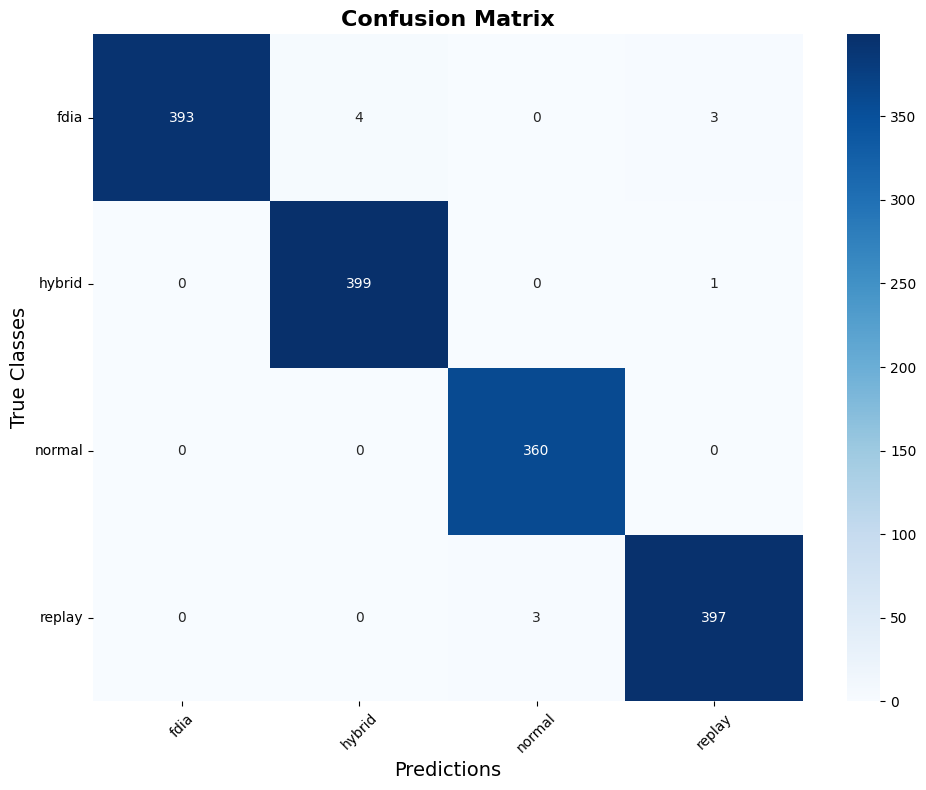


 DISTRIBUTION DES PREDICTIONS
REpartition des predictions:
  fdia: 393 (25.2%)
  hybrid: 403 (25.8%)
  normal: 363 (23.3%)
  replay: 401 (25.7%)

 Distribution reelle vs predite
Actual distribution:
  fdia: 400 (25.6%)
  hybrid: 400 (25.6%)
  normal: 360 (23.1%)
  replay: 400 (25.6%)


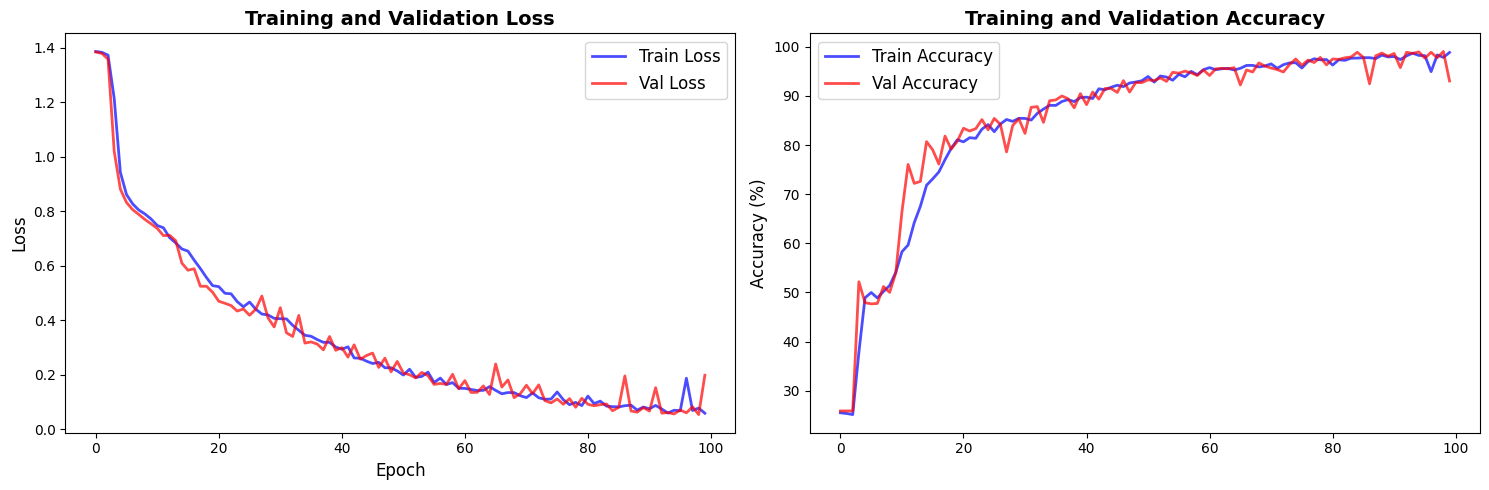


 Entrainement GPU termine avec 99.29% d'accuracy sur le test
Memoire GPU nettoyee


In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

class LSTMModel(nn.Module):
    def __init__(self, input_size=7, hidden_size_1=512, hidden_size_2=256,
                 hidden_size_3=128, num_classes=4, dropout=0.4):
        super(LSTMModel, self).__init__()

        # Couches LSTM SANS dropout (car num_layers=1)
        self.lstm = nn.LSTM(input_size, hidden_size_1, batch_first=True)
        self.lstm1 = nn.LSTM(hidden_size_1, hidden_size_2, batch_first=True)
        self.lstm2 = nn.LSTM(hidden_size_2, hidden_size_3, batch_first=True)

        # Dropout manuel entre les couches LSTM
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

        # Couche de classification finale
        self.classifier = nn.Linear(hidden_size_3, num_classes)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        lstm_out = self.dropout1(lstm_out)

        lstm1_out, _ = self.lstm1(lstm_out)
        lstm1_out = self.dropout2(lstm1_out)

        lstm2_out, _ = self.lstm2(lstm1_out)

        # Prendre le dernier timestep
        last_output = lstm2_out[:, -1, :]

        # Dropout avant la classification
        last_output = self.dropout3(last_output)

        # Classification finale
        output = self.classifier(last_output)

        return output

# Creer le modele et le deplacer sur GPU
model = LSTMModel(
    input_size=7,
    hidden_size_1 = 512,
    hidden_size_2 = 256,
    hidden_size_3 = 128,
    num_classes=4,
    dropout=0.4
)

def train_pytorch(X_train, y_train, X_val, y_val, X_test, y_test):

    # Verification de la disponibilite du GPU
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device utilise: {device}")

    if torch.cuda.is_available():
        print(f"GPU: {torch.cuda.get_device_name(0)}")
        print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    else:
        print("Aucun GPU détecte, utilisation du CPU")

    # Parametres du modele d'entrainement
    input_size = X_train.shape[2]  # 7 features
    hidden_size_1 = 512
    hidden_size_2 = 256
    hidden_size_3 = 128
    num_classes = len(np.unique(y_train))
    batch_size = 64
    epochs = 100
    learning_rate = 1e-5
    dropout = 0.4

    print(f"\nPARAMETRES D'ENTRAINEMENT")
    print(f"Input size: {input_size}, Hidden sizes: {hidden_size_1} -> {hidden_size_2} -> {hidden_size_3}")
    print(f"Num classes: {num_classes}, Batch size: {batch_size}, Epochs: {epochs}")
    print(f"Learning rate: {learning_rate}, Dropout: {dropout}")

    # Creation du modele
    model = LSTMModel(
        input_size=input_size,
        hidden_size_1=hidden_size_1,
        hidden_size_2=hidden_size_2,
        hidden_size_3=hidden_size_3,
        num_classes=num_classes,
        dropout=dropout
    )

    # Deplacement du modele sur le GPU
    model = model.to(device)
    print(f"\nModele cree avec {sum(p.numel() for p in model.parameters()):,} parametres")

    # Preparation des donnees et de les deplacer sur le GPU
    X_train_tensor = torch.FloatTensor(X_train).to(device)
    y_train_tensor = torch.LongTensor(y_train).to(device)
    X_val_tensor = torch.FloatTensor(X_val).to(device)
    y_val_tensor = torch.LongTensor(y_val).to(device)
    X_test_tensor = torch.FloatTensor(X_test).to(device)
    y_test_tensor = torch.LongTensor(y_test).to(device)

    # Chargement des donnees
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=False)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=False)

    from sklearn.utils.class_weight import compute_class_weight

    # Calcul des poids de classes
    classes = np.unique(y_train)
    class_weights = compute_class_weight("balanced", classes=classes, y=y_train)
    weights = torch.tensor(class_weights, dtype=torch.float).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-7)
    criterion = nn.CrossEntropyLoss(weight=weights)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20, min_lr=1e-7)

    # Utilisation des metriques d'entrainement
    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    best_val_loss = float('inf')
    patience_counter = 0
    early_stopping_patience = 20

    print(f"\n DEBUT DE L'ENTRAINEMENT")
    print(f"Nombre d'epoques: {epochs}")
    print(f"Taille du batch: {batch_size}")
    print(f"Echantillons d'entrainement: {len(X_train)}")
    print(f"Echantillons de validation: {len(X_val)}")
    print(f"Echantillons de test: {len(X_test)}")

    for epoch in range(epochs):
        start_time = time.time()

        # Difinition du Mode d'entrainement
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        # Entrainement sans barre de progression
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()

            # Forward pass
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)

            # Backward pass
            loss.backward()
            optimizer.step()

            # Metriques
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += batch_y.size(0)
            train_correct += (predicted == batch_y).sum().item()

        # Definition du mode d'evaluation
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)

                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += batch_y.size(0)
                val_correct += (predicted == batch_y).sum().item()

        # Calcul des moyennes
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        train_accuracy = 100 * train_correct / train_total
        val_accuracy = 100 * val_correct / val_total

        # Stockage des metriques
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accuracies.append(train_accuracy)
        val_accuracies.append(val_accuracy)
        scheduler.step(avg_val_loss)

        # Calcul du temps par epoque
        epoch_time = time.time() - start_time

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"{len(train_loader)}/{len(train_loader)} [==============================] - {epoch_time:.0f}s {epoch_time*1000:.0f}ms/step - "
              f"loss: {avg_train_loss:.4f} - accuracy: {train_accuracy/100:.4f} - "
              f"val_loss: {avg_val_loss:.4f} - val_accuracy: {val_accuracy/100:.4f}")

        # Early stopping permet de ne pas faire du surapprentissage
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), 'pytorch_model.pth')
        else:
            patience_counter += 1
            if patience_counter >= early_stopping_patience:
                print(f"\nEarly stopping à l'epoch {epoch+1}")
                break

    print(f"\n{'='*60}")
    print(f"ENTRAINEMENT TERMINE")
    print(f"{'='*60}")

    # Chargement du modele
    model.load_state_dict(torch.load('pytorch_model.pth'))

    print(f"\n{'='*60}")
    print(f"EVALUATION COMPLETE DU MODELE")
    print(f"{'='*60}")

    model.eval()
    with torch.no_grad():
        # Faire des predictions sur le test
        print(" Evaluation sur le jeu de test")
        test_outputs = model(X_test_tensor)
        test_loss = criterion(test_outputs, y_test_tensor).item()

        # Convertir en probabilites et predictions
        test_probs = torch.softmax(test_outputs, dim=1)
        test_predicted = torch.argmax(test_outputs, dim=1)

        # Convertir en numpy pour sklearn
        y_test_np = y_test_tensor.cpu().numpy()
        y_pred_np = test_predicted.cpu().numpy()
        test_probs_np = test_probs.cpu().numpy()

        # Test Loss et Test Accuracy
        test_accuracy = 100 * (y_pred_np == y_test_np).sum() / len(y_test_np)
        print(f"\n TEST PERFORMANCE")
        print(f"Test Loss : {test_loss:.4f}")
        print(f"Test Accuracy : {test_accuracy:.4f}%")

        print(f"\n METRIQUES DETAILLEES")
        accuracy = accuracy_score(y_test_np, y_pred_np)
        precision = precision_score(y_test_np, y_pred_np, average='macro', zero_division=0)
        recall = recall_score(y_test_np, y_pred_np, average='macro', zero_division=0)
        f1 = f1_score(y_test_np, y_pred_np, average='macro', zero_division=0)

        print(f"Accuracy: {accuracy:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1-score: {f1:.4f}")

        # Classification Report complet du modele
        print(f"\n CLASSIFICATION FULL REPORT")

        # Chargement de l'encodeur pour afficher les 4 classes
        try:
            from joblib import load
            encoder = load("label_encoder.pkl")
            class_names = encoder.classes_
            print(f" Encoder loaded: {len(class_names)} classes")
            print(f"Classes: {list(class_names)}")

            print(f"\n Mapping indexes -> Class name")
            for i, name in enumerate(class_names):
                print(f"  Index {i}: {name}")

        except Exception as e:
            print(f"Impossible de charger l'encodeur: {e}")
            print("Utilisation des noms de classes par defaut")
            class_names = [f'Classe_{i}' for i in range(num_classes)]

        print(classification_report(y_test_np, y_pred_np, target_names=class_names, zero_division=0))

        # Matrice de confusion
        print(f"\n Confusion matrix")
        cm = confusion_matrix(y_test_np, y_pred_np)
        print("Confusion matirx:")
        print("                Prédictions")
        print("                ", end="")
        for name in class_names:
            print(f"{name:>12}", end="")
        print()

        for i, (true_name, row) in enumerate(zip(class_names, cm)):
            print(f"{true_name:>12}", end="")
            for value in row:
                print(f"{value:>12}", end="")
            print()

        # Visualisation de la matrice de confusion
        plt.figure(figsize=(10, 8))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=class_names,
                    yticklabels=class_names)
        plt.title('Confusion Matrix', fontsize=16, fontweight='bold')
        plt.xlabel('Predictions', fontsize=14)
        plt.ylabel('True Classes', fontsize=14)
        plt.xticks(rotation=45)
        plt.yticks(rotation=0)
        plt.tight_layout()
        fig = plt.gcf()
        fig.savefig("matrix.eps", format='eps')
        plt.show()

        # Distribution des prédictions
        print(f"\n DISTRIBUTION DES PREDICTIONS")
        unique, counts = np.unique(y_pred_np, return_counts=True)
        print("REpartition des predictions:")
        for cls, count in zip(unique, counts):
            class_name = class_names[cls]
            print(f"  {class_name}: {count} ({100*count/len(y_pred_np):.1f}%)")

        # Comparaison avec la distribution réelle
        print(f"\n Distribution reelle vs predite")
        real_unique, real_counts = np.unique(y_test_np, return_counts=True)
        print("Actual distribution:")
        for cls, count in zip(real_unique, real_counts):
            class_name = class_names[cls]
            print(f"  {class_name}: {count} ({100*count/len(y_test_np):.1f}%)")

        # Visualisation des courbes d'entrainement
        plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies)

    return model, test_accuracy

def plot_training_history(train_losses, val_losses, train_accuracies, val_accuracies):
    #Visualise l'historique d'entrainement
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Loss
    ax1.plot(train_losses, label='Train Loss', color='blue', alpha=0.7, linewidth=2)
    ax1.plot(val_losses, label='Val Loss', color='red', alpha=0.7, linewidth=2)
    ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.legend(fontsize=12)
    #ax1.grid(True, alpha=0.3)
    ax1.grid(False)

    # Accuracy
    ax2.plot(train_accuracies, label='Train Accuracy', color='blue', alpha=0.7, linewidth=2)
    ax2.plot(val_accuracies, label='Val Accuracy', color='red', alpha=0.7, linewidth=2)
    ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.legend(fontsize=12)
    #ax2.grid(True, alpha=0.3)
    ax2.grid(False)

    plt.tight_layout()
    fig.savefig("training.eps", format='eps')
    plt.show()

# Utilisation
if __name__ == "__main__":
    # Chargement des donnees
    X_train = np.load("X_train.npy")
    X_test = np.load("X_test.npy")
    y_train = np.load("y_train.npy")
    y_test = np.load("y_test.npy")

    # Split validation
    val_size = int(0.2 * len(X_train))
    X_val = X_train[-val_size:]
    y_val = y_train[-val_size:]
    X_train = X_train[:-val_size]
    y_train = y_train[:-val_size]

    print(f"Train: {X_train.shape}, {y_train.shape}")
    print(f"Val: {X_val.shape}, {y_val.shape}")
    print(f"Test: {X_test.shape}, {y_test.shape}")

    # Permet de nettoyer la memoire GPU avant de commencer
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        print("Mémoire GPU nettoyee")

    # Entrainement du modele avec le GPU
    model, test_accuracy= train_pytorch(X_train, y_train, X_val, y_val, X_test, y_test)

    print(f"\n Entrainement GPU termine avec {test_accuracy:.2f}% d'accuracy sur le test")

    # Permet de nettoyer la memoire GPU apres entrainement
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        print("Memoire GPU nettoyee")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')